# Logistic and linear regression with deterministic and stochastic first order methods

    Lab 2 : Optimisation - DataScience Master
    Authors : Alexandre Gramfort, Hicham Janati
   
The aim of this lab is to implement and compare various batch and stochastic algorithms for linear and logistic regression with ridge penalization.

The following methods are compared in this notebook.

**Batch (deterministic) methods**

- gradient descent (GD)
- accelerated gradient descent (AGD)

**Stochastic algorithms**

- stochastic gradient descent (SGD)
- stochastic averaged gradient (SAG)
- stochastic variance reduced gradient (SVRG)

Note that we consider as use-cases logistic and linear regression with ridge penalization only, although most of the algorithms below can be used with many other models, and other types of penalization, even non-smooth ones, such as the $\ell_1$ penalization.


## VERY IMPORTANT

- This work **must be done by pairs of students**.
- **Each** student must send their work **before the 14th of November at 23:55**, using the **moodle platform**.
- This means that **each student in the pair sends the same file**
- The **name of the file must be** constructed as in the next cell

### How to construct the name of your file

In [48]:
# Change here using YOUR first and last names
fn1 = "nicolas"
ln1 = "saint"
fn2 = "matthis"
ln2 = "guerin"

filename = "_".join(map(lambda s: s.strip().lower(),
                        ["lab2", ln1, fn1, "and", ln2, fn2])) + ".ipynb"
print(filename)

lab2_saint_nicolas_and_guerin_matthis.ipynb


# Gentle reminder: no evaluation if you don't respect this EXACTLY

### Table of content

[1. Loss functions, gradients and step-sizes](#loss)<br>
[2. Generate a dataset](#data)<br>
[3. Deterministic methods](#batch)<br>
[4. Stochastic methods](#stoc)<br>
[5. Numerical comparison](#comp)<br>
[6. Conclusion](#conc)<br>

In [49]:
%matplotlib inline

In [50]:
from time import time

import numba
import numpy as np
from scipy.linalg import norm
import matplotlib.pyplot as plt
from numba import njit

In [51]:
# choose a large font size by default and use tex for math
usetex = False  # change this to True if you have a working LaTeX install

fontsize = 16
params = {
    "axes.labelsize": fontsize + 2,
    "font.size": fontsize + 2,
    "legend.fontsize": fontsize + 2,
    "xtick.labelsize": fontsize,
    "ytick.labelsize": fontsize,
    "text.usetex": usetex,
}
plt.rcParams.update(params)

<a id='numba'></a>
## 0. Make sure Numba is correctly installed
Instructions available at: http://numba.pydata.org/numba-doc/latest/user/installing.html

In [52]:
print(numba.__version__) # Your version of Numba

0.58.1


In [53]:
@njit
def go_fast(a): # Function is compiled to machine code when called the first time
    trace = 0.0
    # assuming square input matrix
    for i in range(a.shape[0]):   # Numba likes loops
        trace += np.tanh(a[i, i]) # Numba likes NumPy functions
    return a + trace              # Numba likes NumPy broadcasting

x = np.arange(100).reshape(10, 10)
x = x.astype(float)
go_fast(x) # Running a first time the function to compile it

array([[  9.,  10.,  11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.],
       [ 19.,  20.,  21.,  22.,  23.,  24.,  25.,  26.,  27.,  28.],
       [ 29.,  30.,  31.,  32.,  33.,  34.,  35.,  36.,  37.,  38.],
       [ 39.,  40.,  41.,  42.,  43.,  44.,  45.,  46.,  47.,  48.],
       [ 49.,  50.,  51.,  52.,  53.,  54.,  55.,  56.,  57.,  58.],
       [ 59.,  60.,  61.,  62.,  63.,  64.,  65.,  66.,  67.,  68.],
       [ 69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,  77.,  78.],
       [ 79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,  88.],
       [ 89.,  90.,  91.,  92.,  93.,  94.,  95.,  96.,  97.,  98.],
       [ 99., 100., 101., 102., 103., 104., 105., 106., 107., 108.]])

In [54]:
np.tanh(0)+ np.tanh(10) + np.tanh(20)

1.9999999958776926

Iteration time of the Numba-compiled function.

In [55]:
%timeit go_fast(x)

1.4 µs ± 430 ns per loop (mean ± std. dev. of 7 runs, 1000000 loops each)


Numba-compiled function have a special `.py_func` attribute which is the original uncompiled Python function.  Iteration time of the uncompiled function should be greater.

In [56]:
%timeit go_fast.py_func(x)

21.2 µs ± 5.5 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


<a id='loss'></a>
## 1. Loss functions, gradients and step-sizes


We want to minimize
$$
\frac 1n \sum_{i=1}^n \ell(a_i^\top x, b_i) + \frac \lambda 2 \|x\|_2^2
$$
where
- $\ell(z, b) = \frac 12 (b - z)^2$ (least-squares regression)
- $\ell(z, b) = \log(1 + \exp(-bz))$ (logistic regression).

We write it as a minimization problem of the form
$$
\frac 1n \sum_{i=1}^n f_i(x)
$$
where
$$
f_i(x) = \ell(a_i^\top x, b_i) + \frac \lambda 2 \|x\|_2^2.
$$

For each cases, the gradients are
$$
\nabla f_i(x) = (a_i^\top x - b_i) a_i + \lambda x
$$
and
$$
\nabla f_i(x) = - \frac{b_i}{1 + \exp(b_i a_i^\top x)} a_i + \lambda x.
$$

Denote by $L$ (resp. $L_i$) the Lipschitz constant of $f$ (resp. $f_i$) and $\mathbf A^\top = [a_1, \ldots, a_n].$
One can easily see (using $\|\cdot\|_{2}$ for the matrix spectrale norm) that for least-squares regression
$$
L = \frac{ \|\mathbf A^\top \mathbf A \|_{2}}{n} + \lambda \quad \text{ and } L_i = \| a_i \|_2^2 + \lambda
$$
while for logistic regression it is
$$
L = \frac{ \|\mathbf A^\top \mathbf A \|_{2}}{4 n} + \lambda \quad \text{ and } L_i = \frac 14 \| a_i \|_2^2 + \lambda.
$$
For full-gradient methods, the theoretical step-size is $1 / L$, while for SAG and SVRG (see below) it can be taken as
$1 / (\max_{i=1,\ldots,n} L_i)$

We now introduce functions that will be used for the solvers.


In [57]:
@njit
def grad_i_linreg(i, x, A, b, lbda):
    """Gradient with respect to a sample"""
    a_i = A[i]
    return (a_i.dot(x) - b[i]) * a_i + lbda * x


@njit
def grad_linreg(x, A, b, lbda):
    """Full gradient"""
    g = np.zeros_like(x)
    for i in range(n):
        g += grad_i_linreg(i, x, A, b, lbda)
    return g / n


def loss_linreg(x, A, b, lbda):
    return norm(A.dot(x) - b) ** 2 / (2. * n) + lbda * norm(x) ** 2 / 2.


def lipschitz_linreg(A, b, lbda):
    return norm(A, ord=2) ** 2 / n + lbda

In [58]:
@njit
def grad_i_logreg(i, x, A, b, lbda):
    """Gradient with respect to a sample"""
    a_i = A[i]
    b_i = b[i]
    return - a_i * b_i / (1. + np.exp(b_i * np.dot(a_i, x))) + lbda * x


@njit
def grad_logreg(x, A, b, lbda):
    """Full gradient"""
    g = np.zeros_like(x)
    for i in range(n):
        g += grad_i_logreg(i, x, A, b, lbda)
    return g / n


def loss_logreg(x, A, b, lbda):
    bAx = b * np.dot(A, x)
    return np.mean(np.log(1. + np.exp(- bAx))) + lbda * norm(x) ** 2 / 2.


def lipschitz_logreg(A, b, lbda):
    return norm(A, ord=2) ** 2 / (4. * n) + lbda

<a id='data'></a>
## 2. Generate a dataset

We generate datasets for the least-squares and the logistic cases. First we define a function for the least-squares case.

In [59]:
from numpy.random import multivariate_normal, randn
from scipy.linalg import toeplitz


def simu_linreg(x, n, std=1., corr=0.5):
    """Simulation for the least-squares problem.

    Parameters
    ----------
    x : ndarray, shape (d,)
        The coefficients of the model
    n : int
        Sample size
    std : float, default=1.
        Standard-deviation of the noise
    corr : float, default=0.5
        Correlation of the features matrix

    Returns
    -------
    A : ndarray, shape (n, d)
        The design matrix.
    b : ndarray, shape (n,)
        The targets.
    """
    d = x.shape[0]
    cov = toeplitz(corr ** np.arange(0, d))
    A = multivariate_normal(np.zeros(d), cov, size=n)
    noise = std * randn(n)
    b = A.dot(x) + noise
    return A, b

In [60]:
def simu_logreg(x, n, std=1., corr=0.5):
    """Simulation for the logistic regression problem.

    Parameters
    ----------
    x : ndarray, shape (d,)
        The coefficients of the model
    n : int
        Sample size
    std : float, default=1.
        Standard-deviation of the noise
    corr : float, default=0.5
        Correlation of the features matrix

    Returns
    -------
    A : ndarray, shape (n, d)
        The design matrix.
    b : ndarray, shape (n,)
        The targets.
    """
    A, b = simu_linreg(x, n, std=1., corr=corr)
    return A, np.sign(b)

In [61]:
d = 50
n = 10000
idx = np.arange(d)

# Ground truth coefficients of the model
x_model_truth = (-1)**idx * np.exp(-idx / 10.)

_A, _b = simu_linreg(x_model_truth, n, std=1., corr=0.1)
#_A, _b = simu_logreg(x_model_truth, n, std=1., corr=0.7)

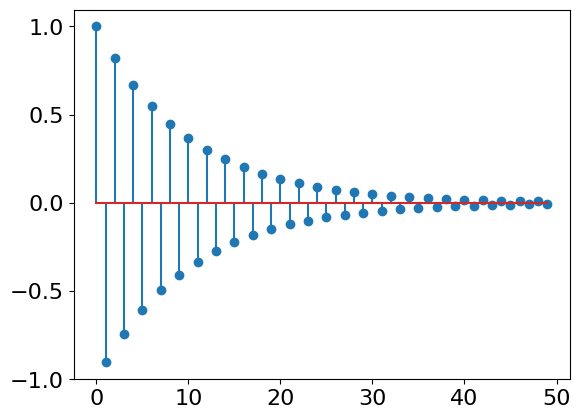

In [62]:
plt.stem(x_model_truth);

### Numerically check loss and gradient

In [63]:
from scipy.optimize import check_grad

lbda = 1. / n ** (0.5)

A, b = simu_linreg(x_model_truth, n, std=1., corr=0.1)
# Check that the gradient and the loss numerically match
check_grad(loss_linreg, grad_linreg, np.random.randn(d), A, b, lbda)

2.2439066796484406e-06

In [64]:
lbda = 1. / n ** (0.5)

A, b = simu_logreg(x_model_truth, n, std=1., corr=0.1)
# Check that the gradient and the loss numerically match
check_grad(loss_logreg, grad_logreg, np.random.randn(d), A, b, lbda)

1.7152255099681993e-07

### Choice of the model

In [65]:
A, b = simu_linreg(x_model_truth, n, std=1., corr=0.9)
loss = loss_linreg
grad = grad_linreg
grad_i = grad_i_linreg
lipschitz_constant = lipschitz_linreg
lbda = 1. / n ** (0.5)

### Compute the theoretical step-size for gradient descent

In [66]:
step = 1. / lipschitz_constant(A, b, lbda)

print("step = %s" % step)

step = 0.0616936296789534


### Get a very precise minimum to compute distances to minimum

Here we use L-BFGS that you have not seen yet. Just take the estimated `x_min` and move on.
You will see L-BFGS later in the course.

In [67]:
from scipy.optimize import fmin_l_bfgs_b

x_init = np.zeros(d)
x_min, f_min, _ = fmin_l_bfgs_b(loss, x_init, grad,
                                args=(A, b, lbda), pgtol=1e-30, factr=1e-30)


print(f_min)
print(norm(grad_linreg(x_min, A, b, lbda)))

0.535519291823385
2.3615413669252943e-08


<a id='batch'></a>

## 3. Deterministic/Batch methods (GD, AGD)

### Define a class to monitor iterations

In [68]:
class monitor:
    def __init__(self, algo, loss, x_min, args=()):
        self.x_min = x_min
        self.algo = algo
        self.loss = loss
        self.args = args
        self.f_min = loss(x_min, *args)

    def run(self, *algo_args, **algo_kwargs):
        t0 = time()
        _, x_list = self.algo(*algo_args, **algo_kwargs)
        self.total_time = time() - t0
        self.x_list = x_list
        self.err = [norm(x - self.x_min) for x in x_list]
        self.obj = [self.loss(x, *self.args) - self.f_min for x in x_list]

In [69]:
# Number of iterations
n_iter = 200

### Gradient descent (GD)

We recall that an iteration of batch gradient writes

$$
x_{k+1} \gets x_k - \eta \nabla f(x_k)
$$

where $\eta$ is the step-size (that can be chosen in theory as $\eta = 1 / L$, with $L$ the Lipshitz constant of $\nabla f$, see above)

*QUESTION*:
- Fill in the iteration of the GD solver in the cell below

In [70]:
@njit
def gd(x_init, grad, n_iter=100, step=1., store_every=1, args=()):
    """Gradient descent algorithm."""
    x = x_init.copy()
    x_list = []
    for i in range(n_iter):
        ### TODO
        x -= step * grad(x, *args)

        if i % store_every == 0:
            x_list.append(x.copy())
    return x, x_list

In [71]:
step = 1. / lipschitz_linreg(A, b, lbda)
x_init = np.zeros(d)
monitor_gd = monitor(gd, loss, x_min, (A, b ,lbda))
monitor_gd.run(x_init, grad, n_iter, step, args=(A, b, lbda))

### Accelerated Gradient Descent (AGD)

We recall that an iteration of AGD (see FISTA) writes:

$$
\begin{align*}
x_{k+1} &\gets y_k - \eta \nabla f(y_k) \\
t_{k+1} &\gets \frac{1 + \sqrt{1 + 4 t_k^2}}{2} \\
y_{k+1} &\gets x_{k+1} + \frac{t_k-1}{t_{k+1}} (x_{k+1} - x_k)
\end{align*}
$$

where $\eta$ is the step-size (that can be chosen in theory as $\eta = 1 / L$, with $L$ the Lipschitz constant of $\nabla f$, see above)

*QUESTION*:
- Fill in the iteration of the AGD solver in the cell below

In [72]:
@njit
def agd(x_init, grad, n_iter=100, step=1., args=(), store_every=1):
    """Accelerated Gradient Descent algorithm."""
    x = x_init.copy()
    y = x_init.copy()
    t = 1.
    x_list = []
    for i in range(n_iter):
        if i % store_every == 0:
            x_list.append(x.copy())
        ### TODO
        x_new = y - step * grad(y, *args)
        t_new = (1 + (1 + 4 * t ** 2) ** 0.5) / 2
        y = x_new + (t - 1) / t_new * (x_new - x)
        x = x_new
        t = t_new

    return x, x_list

In [73]:
step = 1. / lipschitz_linreg(A, b, lbda)
x_init = np.zeros(d)
monitor_agd = monitor(agd, loss, x_min, (A, b ,lbda))
monitor_agd.run(x_init, grad, n_iter, step, args=(A, b, lbda))

### A first numerical comparison of deterministic solvers

First, define some plotting functions.

In [74]:
def plot_epochs(monitors, solvers):
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    for monit in monitors:
        plt.semilogy(monit.obj, lw=2)
        plt.title("Loss")
        plt.xlabel("Epoch")
        plt.ylabel("objective")

    plt.legend(solvers)

    plt.subplot(1, 2, 2)

    for monit in monitors:
        plt.semilogy(monit.err, lw=2)
        plt.title("Distance to optimum")
        plt.xlabel("Epoch")
        plt.ylabel("$\|x_k - x^*\|_2$")

    plt.legend(solvers)


def plot_time(monitors, solvers, xscale='linear', yscale='log'):
    for monit in monitors:
        objs = monit.obj
        plt.semilogy(np.linspace(0, monit.total_time, len(objs)), objs, lw=2)
        plt.title("Loss")
        plt.xlabel("Timing")
        plt.ylabel("$f(x_k) - f(x^*)$")
        plt.yscale(yscale)
        plt.xscale(xscale)

    plt.legend(solvers)

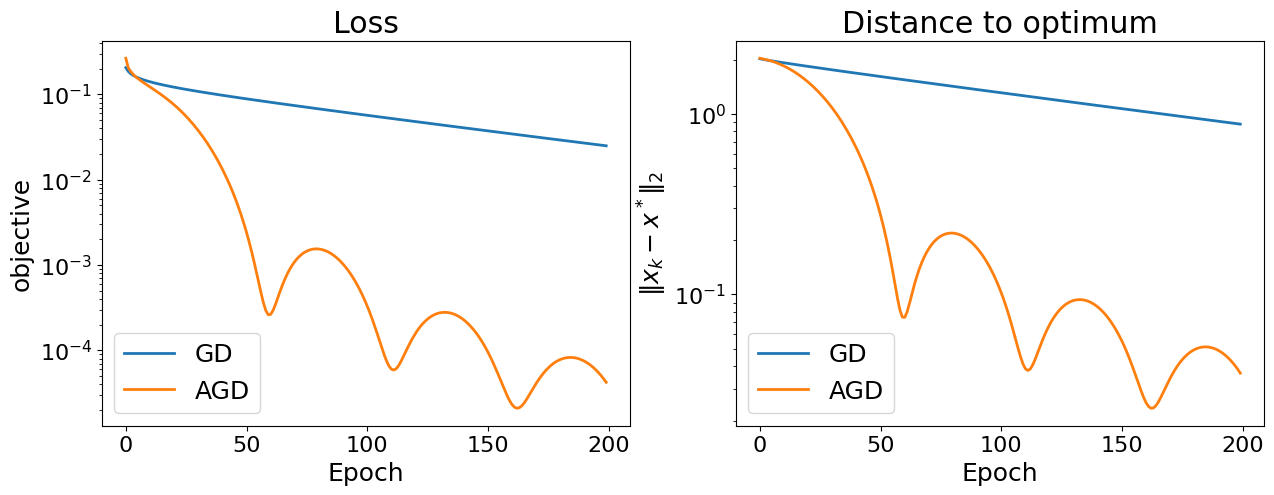

In [75]:
monitors = [monitor_gd, monitor_agd]

solvers = ["GD", "AGD"]

plot_epochs(monitors, solvers)

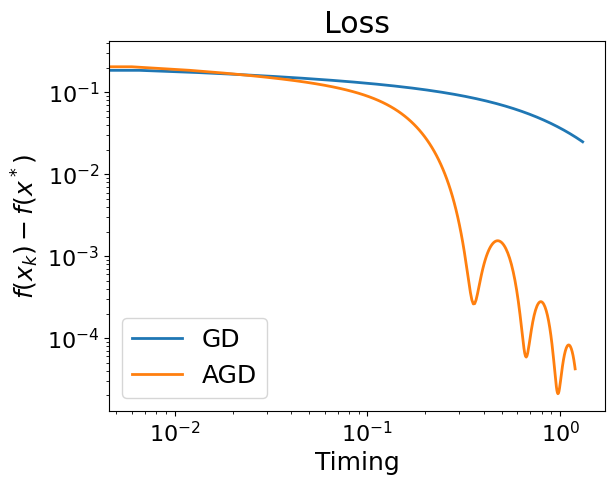

In [76]:
plot_time(monitors, solvers, xscale='log')

### First conclusions

*QUESTIONS*:

- Give some first conclusions about the batch solver studied here
- What do you observe about AGD? is it suprising ?

**Réponse**:

Conclusions:

Accelerated Gradient Descent (AGD) outperforms Gradient Descent (GD) in terms of convergence speed. Around the time $t=10^{-1}$, AGD exhibits a notable acceleration, attributed to the accumulation of sufficient inertia.

In terms of convergence rate ($k$ being the number of iterations):

GD has a convergence rate of $Ο(\frac{1}{k})$.
AGD has a faster convergence rate of $Ο(\frac{1}{k^2})$.
While AGD excels in quickly finding a minimum, it's worth noting that, theoretically, GD may perform better in finding a superior minimizer given more iterations and a smaller input size.

Observations about AGD:

AGD displays noticeable oscillations as it approaches the minimizer. This behavior is a result of the algorithm implementing Momentum, causing the variable $x$ to regularly surpass the minimizer and move away due to Momentum. This leads to fluctuations in the graph, attributed to the changing direction of the gradient and the time it takes for the gradient to shift.

These findings are not suprising as we talked about the difference of these two algorithm's behaviour in class.







<a id='stoc'></a>
## 4. Stochastic methods

In [77]:
n_iter = 50

# generate indices of random samples
random_indices = np.random.randint(0, n, n * n_iter)

### SGD

We recall that an iteration of SGD writes

- Pick $i$ uniformly at random in $\{1, \ldots, n\}$
- Apply
$$
x_{t+1} \gets x_t - \frac{\eta_0}{\sqrt{t+1}} \nabla f_i(x_t)
$$

where $\eta_0$ is a step-size to be tuned by hand.

*QUESTION*:
- Fill in the iteration of the SGD solver in the cell below

In [78]:
@njit
def sgd(x_init, random_indices, grad_i, n_iter=100, step=1., store_every=n, args=()):
    """Stochastic gradient descent algorithm."""
    x = x_init.copy()
    x_list = []
    for idx in range(n_iter):
        i = random_indices[idx]

        ### TODO
        x -= step * ( 1 / ((idx+1) ** 0.5) ) * grad_i(i, x, *args)

        # Update metrics after each iteration.
        if idx % store_every == 0:
            x_list.append(x.copy())
    return x, x_list

In [79]:
step0 = 1e-1
x_init = np.zeros(d)

monitor_sgd = monitor(sgd, loss, x_min, (A, b ,lbda))
monitor_sgd.run(x_init, random_indices, grad_i, n_iter * n, step0, args=(A, b, lbda))

### SAG

We recall that an iteration of SAG writes

For $t=1, \ldots, $ until convergence

1. Pick $i_t$ uniformly at random in $\{1, \ldots, n\}$

2. Update the average of gradients
$$
G_t \gets \frac 1n \sum_{i=1}^n g_i^t
$$
where
$$
g_i^t =
\begin{cases}
    \nabla f_{i}(x_t) &\text{ if } i = i_t \\
    g_i^{t-1} & \text{ otherwise.}
\end{cases}
$$

3. Apply the step
$$x_{t+1} \gets x_t - \eta G_t$$
where $\eta$ is the step-size (see code below).

*QUESTION*:
- Fill in the iteration of the SAG solver in the cell below

In [80]:
@njit
def sag(x_init, random_indices, grad_i, n_iter=100, step=1., store_every=n, args=()):
    """Stochastic average gradient algorithm."""
    x = x_init.copy()
    # Old gradients
    gradient_memory = np.zeros((n, d))
    averaged_gradient = np.zeros(d)
    x_list = []
    for idx in range(n_iter):
        i = random_indices[idx]

        ### TODO
        averaged_gradient -= (1/n) * gradient_memory[i]
        gradient_memory[i] = grad_i(i, x, *args)
        averaged_gradient += (1/n) * gradient_memory[i]
        # Updating the parameter
        x -= step * averaged_gradient

        # Update metrics after each iteration.
        if idx % store_every == 0:
            x_list.append(x.copy())
    return x, x_list

In [81]:
max_squared_sum = np.max(np.sum(A ** 2, axis=1))
step = 1.0 / (max_squared_sum + lbda)

x_init = np.zeros(d)
monitor_sag = monitor(sag, loss, x_min, (A, b ,lbda))
monitor_sag.run(x_init, random_indices, grad_i, n_iter * n, step, args=(A, b, lbda))

### SVRG

We recall that an iteration of SVRG writes

For $k=1, \ldots, $ until convergence

1. Set $\tilde x \gets \tilde x^{(k)}$ and $x_1^{(k)} \gets \tilde x$
2. Compute $\mu_k \gets \nabla f(\tilde x)$
3. For $t=1, \ldots, n$
    4. Pick $i$ uniformly at random in $\{1, \ldots, n\}$
    5. Apply the step
$$
x_{t+1}^{(k)} \gets x_t^{(k)} - \eta \big(\nabla f_{i}(x_t^{(k)}) - \nabla f_{i}(\tilde x) + \mu_k \big)
$$

6. Set $\tilde x^{(k+1)} \gets x_{n+1}^{(k)}$

where $\eta$ is the step-size (see code below).

*QUESTION*:
- Fill in the iteration of the SVRG solver in the cell below

In [82]:
@njit
def svrg(x_init, random_indices, grad, grad_i, n_iter=100, step=1., store_every=n, args=()):
    """Stochastic variance reduction gradient algorithm."""
    x = x_init.copy()
    x_old = x.copy()
    x_list = []
    for idx in range(n_iter):

        ### TODO
        if idx % store_every == 0:
            x_old = x.copy()
            full_grad = grad(x_old, *args)
        i = random_indices[idx]
        x -= step * ( grad_i(i, x, *args) - grad_i(i, x_old, *args) + full_grad )

        # Update metrics after each iteration.
        if idx % store_every == 0:
            x_list.append(x.copy())
    return x, x_list

In [83]:
x_init = np.zeros(d)
monitor_svrg = monitor(svrg, loss, x_min, (A, b ,lbda))
monitor_svrg.run(x_init, random_indices, grad, grad_i, n_iter * n, step, args=(A, b, lbda))

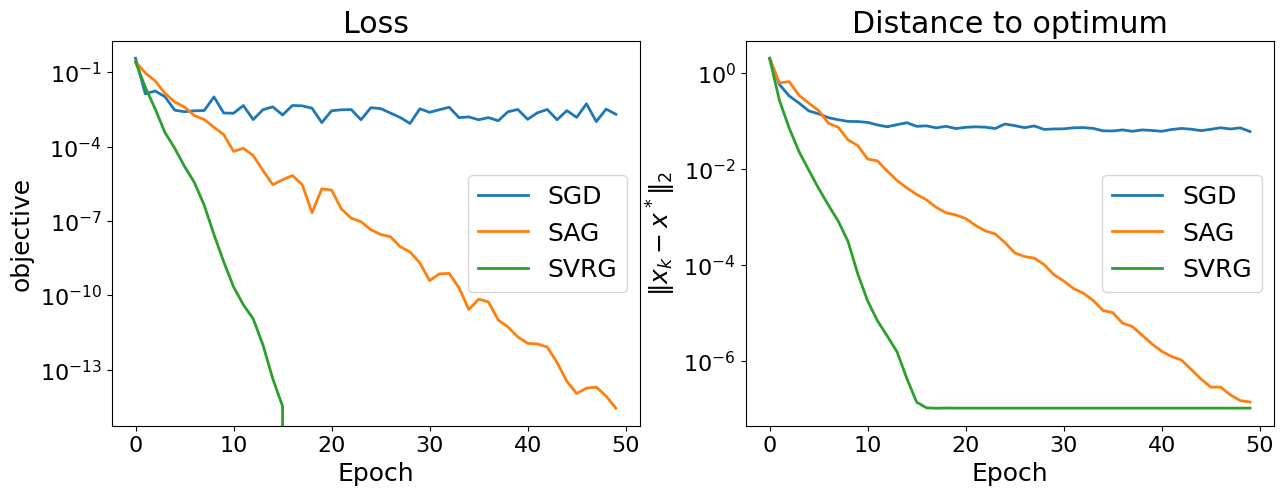

In [84]:
monitors = [monitor_sgd, monitor_sag, monitor_svrg]

solvers = ["SGD", "SAG", "SVRG"]

plot_epochs(monitors, solvers)

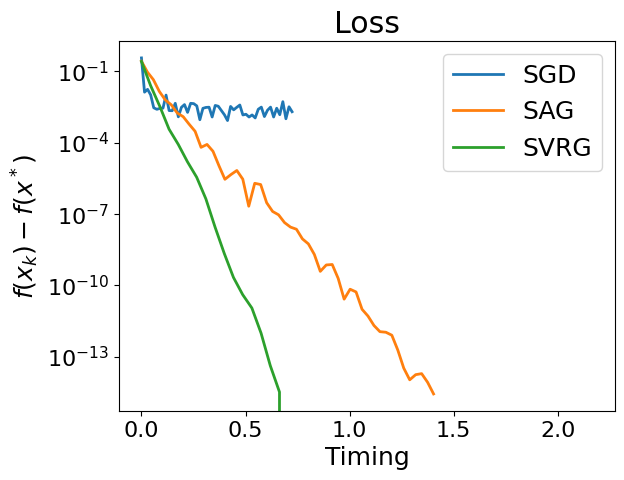

In [85]:
plot_time(monitors, solvers)

<a id='comp'></a>
## 5. Numerical comparison

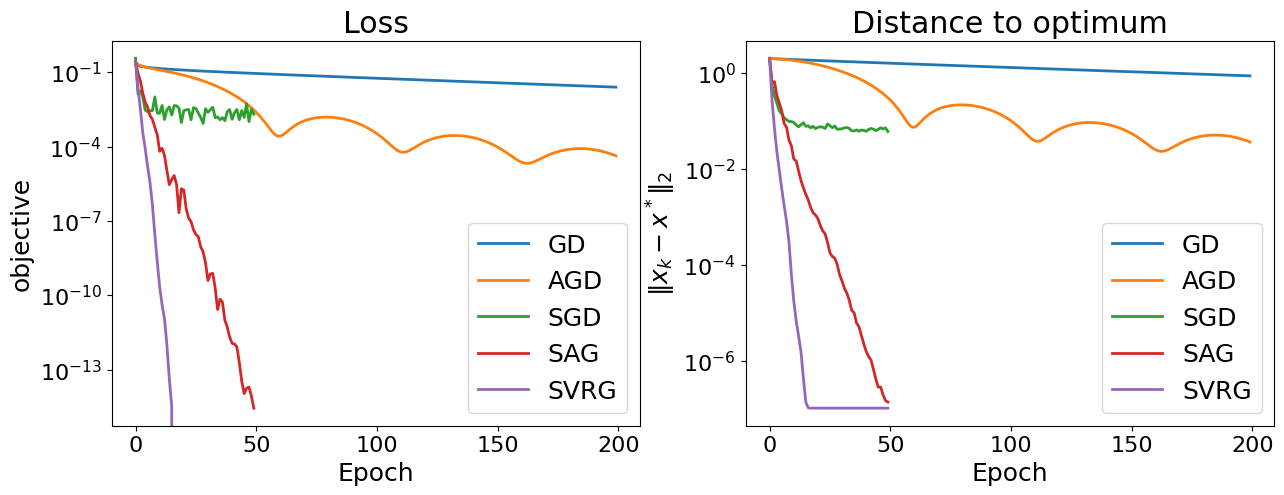

In [86]:
monitors = [monitor_gd, monitor_agd,
            monitor_sgd, monitor_sag, monitor_svrg]

solvers = ["GD", "AGD", "SGD", "SAG", "SVRG"]

plot_epochs(monitors, solvers)

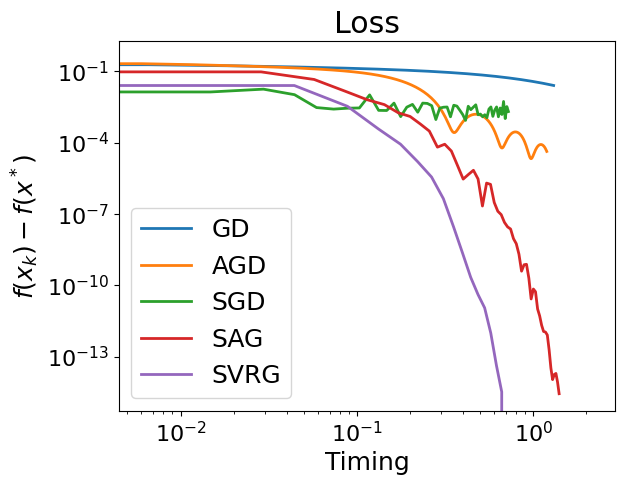

In [87]:
plot_time(monitors, solvers, xscale='log')

<a id='conc'></a>
## 6. Conclusion

*QUESTIONS*:

1) Compare and comment your results


SGD vs. GD & AGD:

**SGD** converges faster than **GD** and **AGD** towards a minimizer, seemingly of similar magnitude.
A note emphasizes that the minimizer is not shared between **GD** and **SGD**; **GD**'s minimizer ends up lower.
**SGD**'s minimum becomes more stable near the minimizer but suffers from variance issues.
**SAG**:

**SAG** exhibits faster convergence towards a smaller minimizer, thanks to variance control through memory.
The preference for updating specific dimensions rather than the entire algorithm at each iteration enhances speed.
**SVRG**:

SVRG is the fastest algorithm, converging towards the smallest minimizer, attributed to variance reduction.
The difficulty of implementing SVRG is linked to an extra parameter in the inner loop.
Complexity Comparison:

Timing and Complexity:

Definitions:
$ϵ$: desired precision
$n$: number of iterations
$L$: smoothness constant
$μ$: strongness constant
Total complexities:
SGD: $𝐎(\frac{1}{ϵ})$
GD: $𝐎(\frac{nL}{μ}\log\frac{1}{ϵ})$
SAG / SVRG: $𝐎(n + \frac{L_{\text{max}}}{μ}\log{\frac{1}{ϵ}})$
Comparison:

SVRG and SAG outperform GD when $L\ge \mu + \frac{L_{\text{max}}}{n}$ (which is the case here).
Precision Consideration:

It's suggested that precision ($ϵ$) might not be crucial in machine learning as the focus is on generalization rather than absolute precision.

2) Change the value of the ridge regularization (the ``lbda`` parameter) to low ridge $\lambda = 1 / n$ and high ridge regularization $\lambda = 1$ and compare your results. Comment.


In [88]:
def plot_epochs(monitors, solvers, title):
    fig, axes = plt.subplots(1, 3, figsize=(25, 5))

    for ax in axes:
        for monit in monitors:
            if ax == axes[0]:
                ax.semilogy(monit.obj, lw=2)
                ax.set(title=f"{title} | Loss per epoch", xlabel="Epoch", ylabel="objective")
            elif ax == axes[1]:
                ax.semilogy(monit.err, lw=2)
                ax.set(title=f"{title} | Distance to optimum", xlabel="Epoch", ylabel="$\|x_k - x^*\|_2$")
            else:
                objs = monit.obj
                ax.semilogy(np.linspace(0, monit.total_time, len(objs)), objs, lw=2)
                ax.set(title=f"{title} | Loss timing", xlabel="Timing", ylabel="$f(x_k) - f(x^*)$")
                ax.set_yscale("log")
                ax.set_xscale("linear")

        ax.legend(solvers)



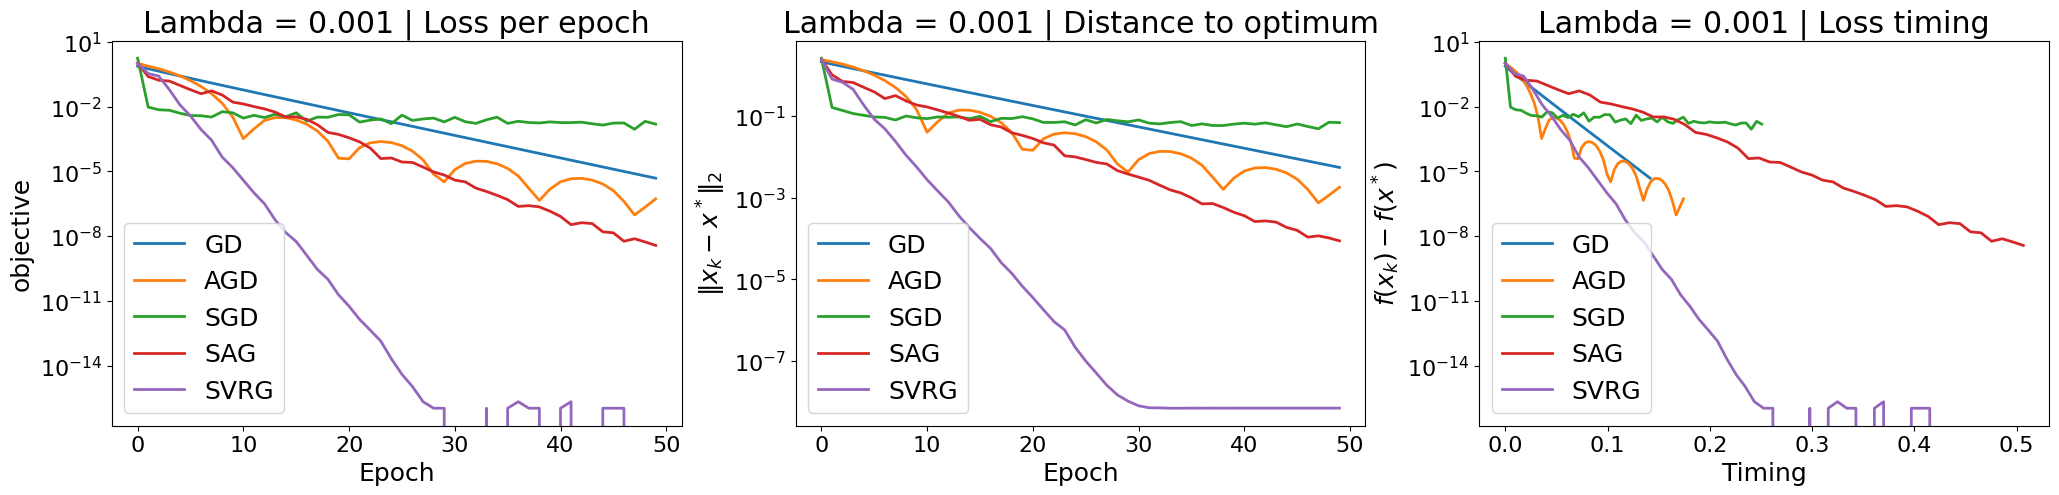

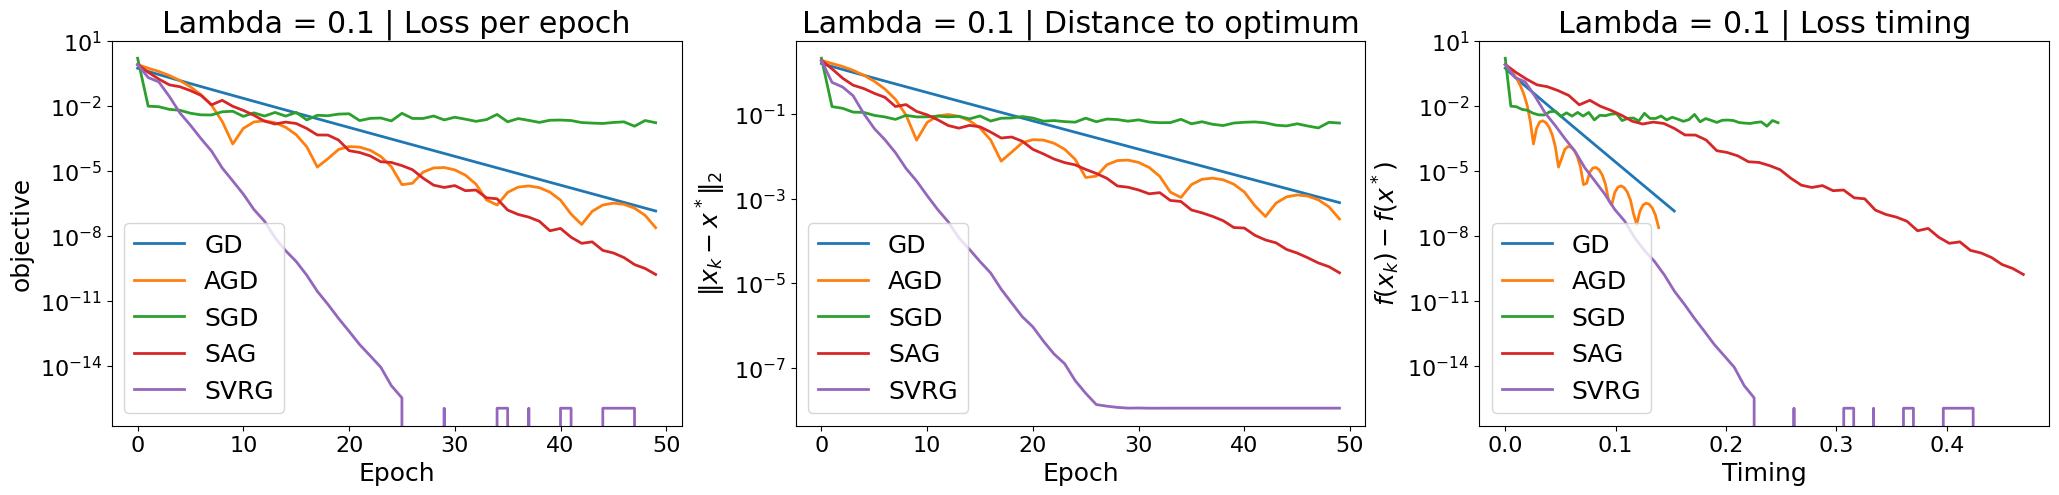

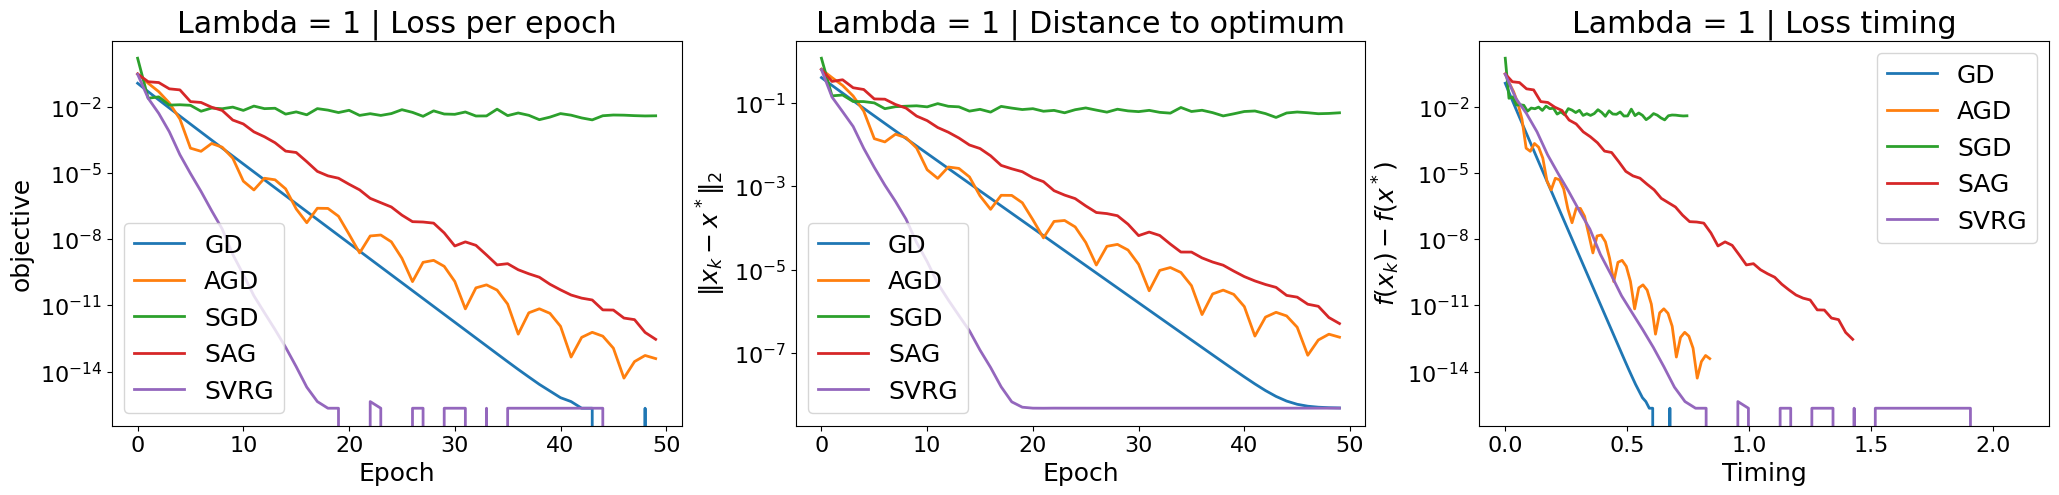

In [89]:
# Restarting the linear regression simulation
A, b = simu_linreg(x_model_truth, n, std=1., corr=0.5)
grad = grad_linreg
grad_i = grad_i_linreg

# Establishing the list of lambdas (0.01, 0.0001, 1)
lbda_values = [0.001, 0.1, 1]

for lbda in lbda_values:
    # Compute steps
    step = {
        "gd": 1. / lipschitz_linreg(A, b, lbda),
        "agd": 1. / lipschitz_linreg(A, b, lbda),
        "sgd": 1e-1,
        "sag": 1.0 / (np.max(np.sum(A ** 2, axis=1)) + lbda),
        "svrg": 1.0 / (np.max(np.sum(A ** 2, axis=1)) + lbda)
    }

    # Initialize x_init, x_min, f_min according to lbda
    x_init = np.zeros(d)
    x_min, f_min, _ = fmin_l_bfgs_b(loss, x_init, grad, args=(A, b, lbda), pgtol=1e-30, factr=1e-30)

    # Compute each algorithm and collect monitoring data
    # Create and run monitors
    monitor_instances = []
    for alg in [gd, agd, sgd, sag, svrg]:
        monitor_alg = monitor(alg, loss, x_min, (A, b, lbda))
        if alg in [gd, agd]:
            monitor_alg.run(x_init, grad, n_iter, step[alg.__name__], args=(A, b, lbda))
        elif alg in [sgd, sag]:
            monitor_alg.run(x_init, random_indices, grad_i, n_iter * n, step[alg.__name__], args=(A, b, lbda))
        else:
            monitor_alg.run(x_init, random_indices, grad, grad_i, n_iter * n, step[alg.__name__], args=(A, b, lbda))

        monitor_instances.append(monitor_alg)

    # Print each curve
    solvers = ["GD", "AGD", "SGD", "SAG", "SVRG"]
    plot_epochs(monitor_instances, solvers, "Lambda = {}".format(lbda))


We are intrigued by three distinct aspects: the loss function, the proximity to the optimum, and the temporal evolution of the loss. Our benchmark setting involves a standard regularization parameter, denoted as λ=0.01=λr, which serves as a baseline for comparison.

For the case of a lower ridge, λ=0.0001=λl, we observe negligible deviations compared to the reference value, λr. The proximity to the minimum is noticeably closer, especially for SVRG, reaching magnitudes in the order of 10^(-8), a significant improvement over the 10^(-7) range observed for λr. This trend holds for other algorithms as well, converging to a minimum that is tenfold superior. Despite some additional oscillations, the overall timing remains similar, suggesting that the low ridge enhances the optimization's minimum value. This aligns with expectations, given that regularization contributes minimally to the overall equation with such a small λ. The function experiences minimal regularization, resulting in a vast function space. Consequently, the convergence rate decreases, but the attained minimum is superior.

Now, considering a higher ridge, λ=1=λh, we observe faster epoch-wise convergence compared to λr. All algorithms exhibit steeper negative slopes, with some achieving linear convergence, notably GD. The minimum achieved is relatively consistent with that of λr. However, the accelerated convergence results in a lower minimum at time t=50 for all algorithms. The computational timing for all algorithms worsens, indicating increased complexity.

The high ridge appears to enhance the convergence speed at the expense of increased complexity and a less precise minimum, attributed to heightened oscillations. The swifter convergence is likely due to Ridge regularization reducing gradient values, mitigating the negative impact of variance at the start of algorithms. However, this reduction in gradients likely contributes to a convergence towards a higher final minimizer, indicating a less optimal outcome.

In summary, higher regularization factors lead to a narrower function space, enabling quicker minimum discovery due to the increased influence of λ. This is because λ carries more weight in the equation, significantly affecting the function to optimize through substantial regularization.

3) Play also with the level of correlation between features (parameter ``corr`` above), and compare results with low and high correlation.

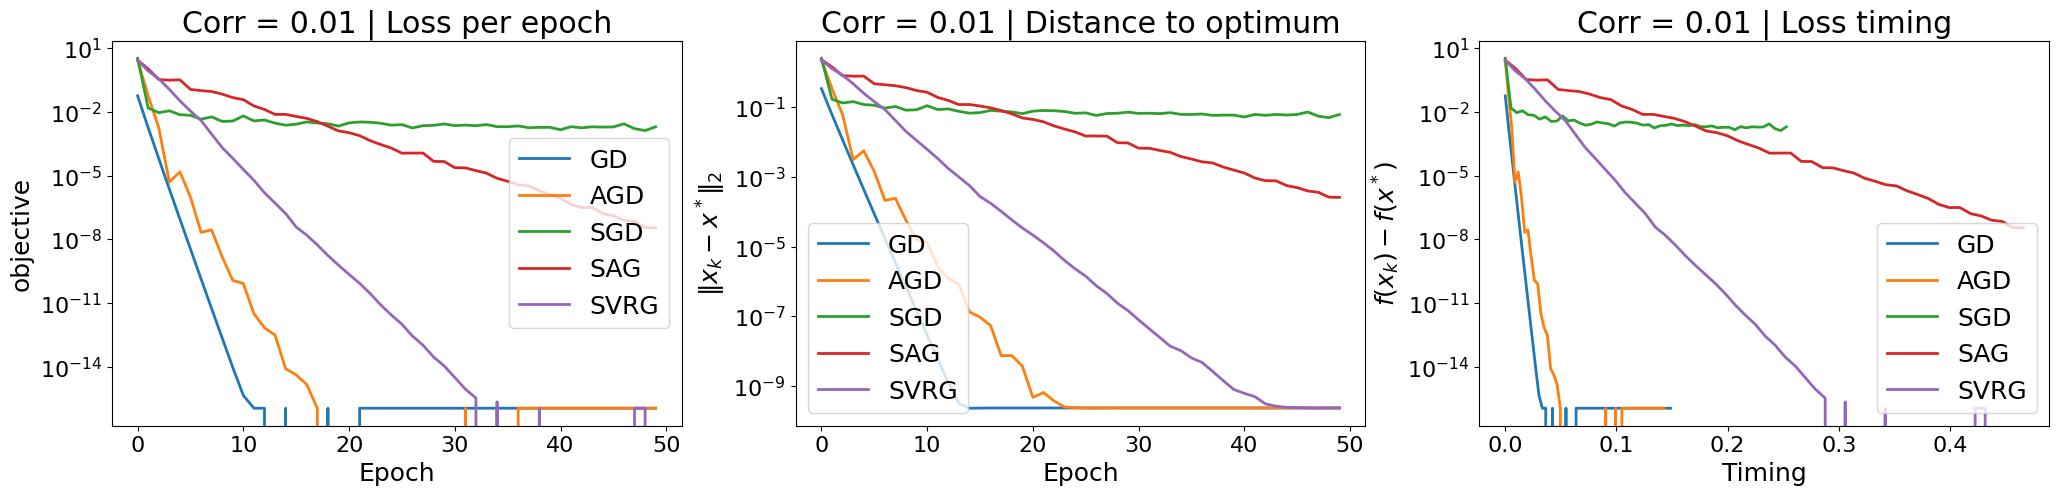

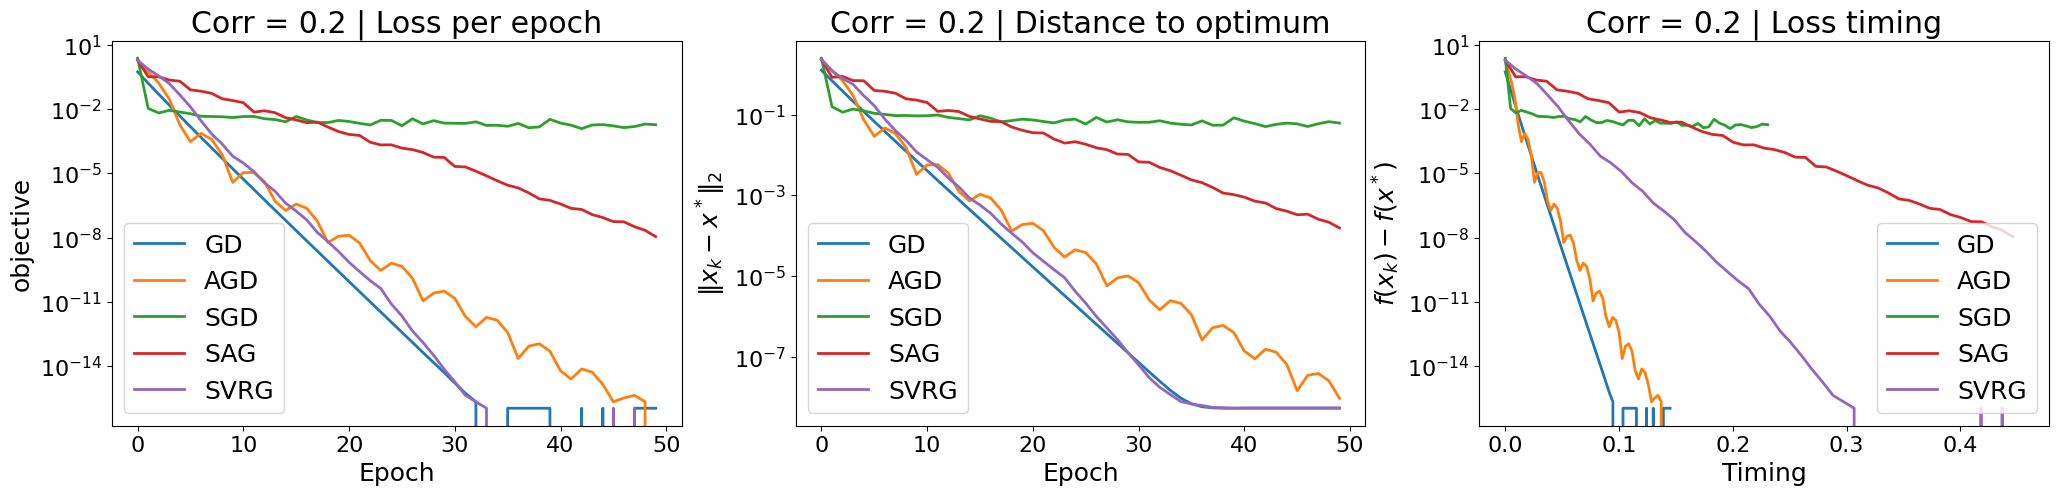

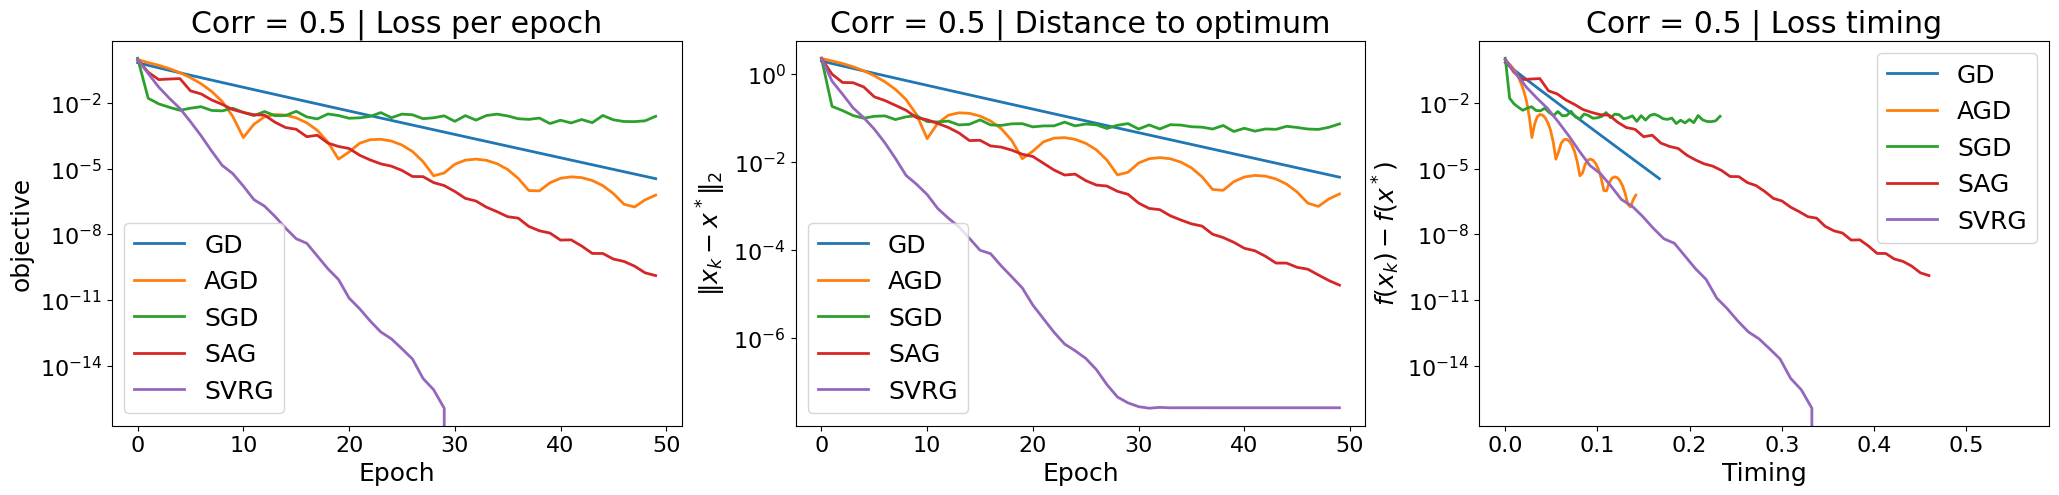

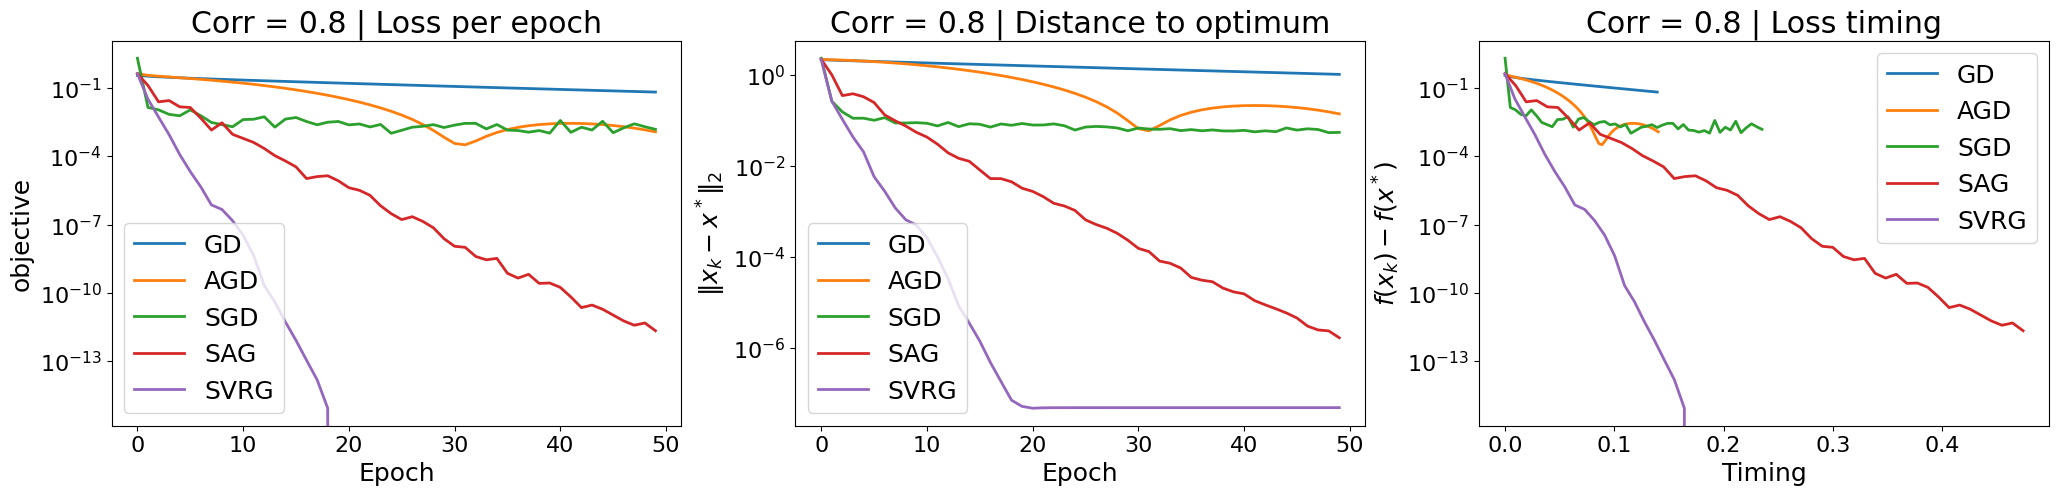

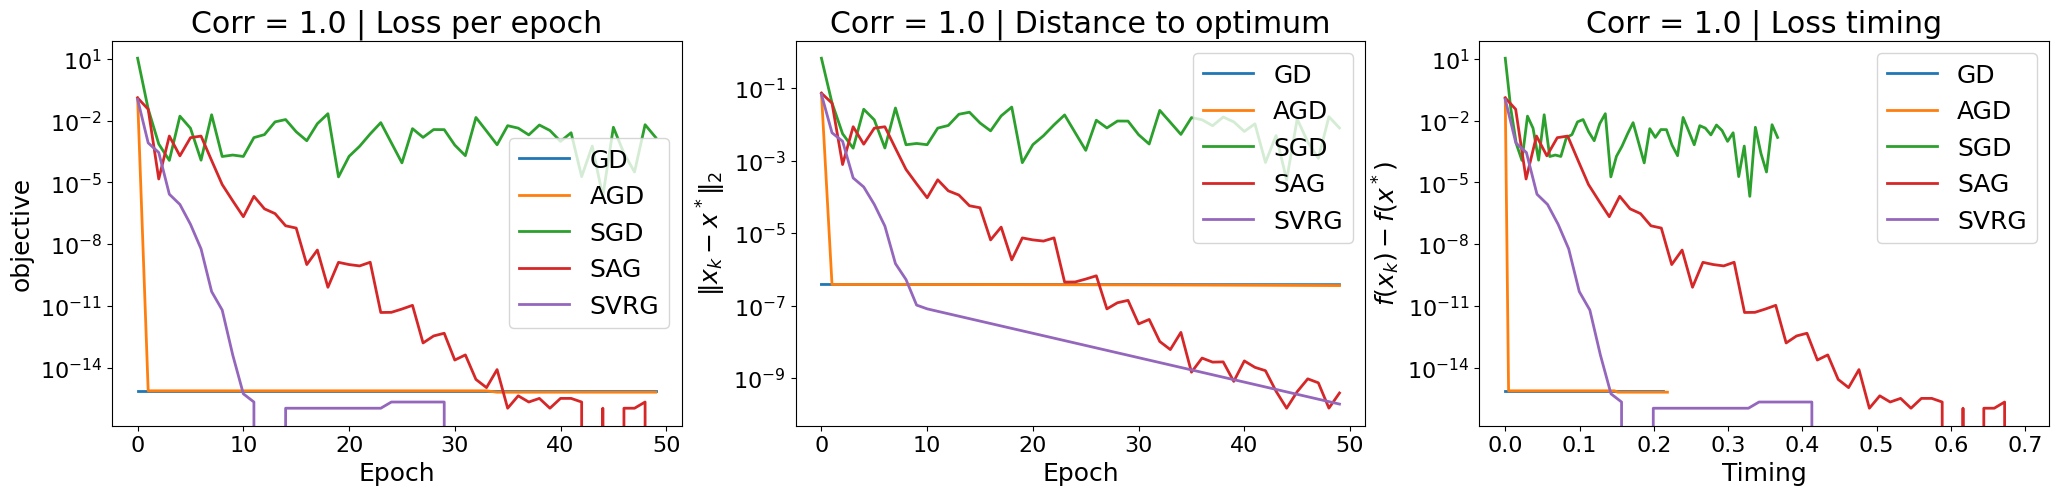

In [90]:
# Creating a correlation list with different values
corr_list = np.array([0.01, 0.2, 0.5, 0.8, 1])

# Setting the lambda at 0.01
lbda = (1. / n ** (0.5))

for corr in corr_list:
    A, b = simu_linreg(x_model_truth, n, std=1., corr=corr)
    grad = grad_linreg
    grad_i = grad_i_linreg

    # Setting the MSS
    max_squared_sum = np.max(np.sum(A ** 2, axis=1))

    # Computing the steps
    step = {"gd": 1. / lipschitz_linreg(A, b, lbda),
            "agd": 1. / lipschitz_linreg(A, b, lbda),
            "sgd": 1e-1,
            "sag": 1.0 / (max_squared_sum + lbda),
            "svrg": 1.0 / (max_squared_sum + lbda)}

    # Init x_init, x_min, f_min according to lbda
    x_init = np.zeros(d)
    x_min, f_min, _ = fmin_l_bfgs_b(loss, x_init, grad,
                                    args=(A, b, lbda), pgtol=1e-30, factr=1e-30)

    # Create and run monitors
    monitor_instances = []
    for alg in [gd, agd, sgd, sag, svrg]:
        monitor_alg = monitor(alg, loss, x_min, (A, b, lbda))
        if alg in [gd, agd]:
            monitor_alg.run(x_init, grad, n_iter, step[alg.__name__], args=(A, b, lbda))
        elif alg in [sgd, sag]:
            monitor_alg.run(x_init, random_indices, grad_i, n_iter * n, step[alg.__name__], args=(A, b, lbda))
        else:
            monitor_alg.run(x_init, random_indices, grad, grad_i, n_iter * n, step[alg.__name__], args=(A, b, lbda))

        monitor_instances.append(monitor_alg)

    # Print each curve
    solvers = ["GD", "AGD", "SGD", "SAG", "SVRG"]
    plot_epochs(monitor_instances, solvers, "Corr = {}".format(corr))


**Réponse** :

In this analysis, we avoided using $corr = 1$ as it resulted in somewhat irrelevant outcomes for the overall study. Observing the impact of correlation on different algorithms, we draw the following conclusions:

- SGD exhibits stable results overall, but becomes unstable with very high correlation.
- SVRG shows good resistance to correlation. Its performance changes moderately between $0.2$ and $0.8$, maintaining effectiveness regardless of the correlation value.
- SAG algorithm maintains stability with low and normal correlation, excelling with high correlation.
- GD and AGD algorithms are highly sensitive to correlation. Their performance varies significantly, excelling with very low correlation, remaining competitive with medium correlation, and becoming almost stationary with high correlation.

A plausible explanation for these observations includes:

- GD and AGD: These algorithms are not resistant to multicollinearity, impacting the learning rate and convergence rate. With low correlation, they perform well, while with high correlation, the learning rate is almost null, resulting in slow convergence.
- SGD: This algorithm is less affected by correlation due to its unique approach of considering one sample per iteration. It stays somewhat stationary around a "bowl" regardless of correlation.
- SAG: Despite the expected impact of correlation on distance, SAG's use of an averaged gradient allows it to benefit fully from correlation, maintaining effective performance.
SVRG: The correlation's impact is likely similar to SAG, and its ability to handle the variance problem contributes to its robust behavior.

In summary, stochastic algorithms, such as SGD, SAG, and SVRG, exhibit favorable behavior with respect to correlation, making them valuable for machine learning applications.

4) Conclude

In conclusion, stochastic algorithms offer notable benefits, demonstrating swift convergence with minimal computational expenses. Specifically, algorithms like SVRG stand out for their efficiency in reaching excellent minimizers and their resilience to correlation impact. SVRG, in particular, proves to be a potent choice for function optimization, delivering superior minimization in fewer iterations, even though each iteration may take longer.

However, in the realm of machine learning, SGD is often preferred over SVRG. This preference for SGD is not thoroughly explored here, but it could stem from certain properties of SVRG, such as its lower variance and better minimizer, which might not align perfectly with the requirements of machine learning tasks. To adapt SVRG for machine learning, there's a need to introduce variance to the algorithm. This is indicated by the addition of a term in the upper bound, fostering variance and aiding generalization.

This necessity for variance has led to the development of BP-SVRG, a SVRG-type algorithm. BP-SVRG is designed to strike a balance, achieving smaller test loss with fewer traversals of the dataset. It serves as a potential bridge between the generalization properties of SGD and the efficient performance of SVRG-type algorithms. Further exploration and testing, particularly regarding the effects of BP-SVRG, could provide valuable insights into enhancing machine learning algorithms.